In [ ]:
%load_ext autoreload
%autoreload 2



In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import generate_graph

In [3]:
from pathlib import Path
import os
import sys

project_root = Path.cwd().resolve().parents[1]
print(project_root)
sys.path.insert(0, str(project_root))

import lib.dataloader as dl


/vol/data/immuneML/cmsb26_project7


In [4]:
df = dl.load_kaggle_dataset("dataset_7")
df

Loading Kaggle dataset: dataset_7
Train path: /vol/data/keggel/train_datasets/train_datasets/train_dataset_7/
Loading cached dataset from /vol/data/keggel/train_datasets/train_datasets/train_dataset_7//_dataset.pkl...


,junction_aa,templates,sample,filename,label_positive,age,sex,race,sequencing_run_id
0,CASSQGADTQYF,1,50024f75d3e748ebda1b140386bdafd8,50024f75d3e748ebda1b140386bdafd8.tsv,False,31,male,White,batch_1
1,CASTSPGKVERRYNEQFF,1,50024f75d3e748ebda1b140386bdafd8,50024f75d3e748ebda1b140386bdafd8.tsv,False,31,male,White,batch_1
2,CASSLGGPGQINNEQFF,1,50024f75d3e748ebda1b140386bdafd8,50024f75d3e748ebda1b140386bdafd8.tsv,False,31,male,White,batch_1
3,CASSFLSSGNTIYF,1,50024f75d3e748ebda1b140386bdafd8,50024f75d3e748ebda1b140386bdafd8.tsv,False,31,male,White,batch_1
4,CAISESSGGAPGELFF,1,50024f75d3e748ebda1b140386bdafd8,50024f75d3e748ebda1b140386bdafd8.tsv,False,31,male,White,batch_1
...,...,...,...,...,...,...,...,...,...
93928783,CASSQDPGLSQYF,1,296e4b7a04e54ba9c3f4c4fb5221200e,296e4b7a04e54ba9c3f4c4fb5221200e.tsv,False,25,male,White,batch_1
93928784,CASSLGGEQYF,2,296e4b7a04e54ba9c3f4c4fb5221200e,296e4b7a04e54ba9c3f4c4fb5221200e.tsv,False,25,male,White,batch_1
93928785,CASSMSGTAYEQYF,1,296e4b7a04e54ba9c3f4c4fb5221200e,296e4b7a04e54ba9c3f4c4fb5221200e.tsv,False,25,male,White,batch_1
93928786,CASGPGQGIRETQYF,1,296e4b7a04e54ba9c3f4c4fb5221200e,296e4b7a04e54ba9c3f4c4fb5221200e.tsv,False,25,male,White,batch_1


In [ ]:
df = generate_graph.top_percent_cutoff(df, p=0.01)
df = df.reset_index(drop=True)
df

,junction_aa,templates,sample,filename,label_positive,age,sex,race,sequencing_run_id,cummulative_perc
0,CASSSEGGTYEQYF,10,50024f75d3e748ebda1b140386bdafd8,50024f75d3e748ebda1b140386bdafd8.tsv,False,31,male,White,batch_1,0.994726
1,CAISDEDRGVYQPQHF,8,50024f75d3e748ebda1b140386bdafd8,50024f75d3e748ebda1b140386bdafd8.tsv,False,31,male,White,batch_1,0.992443
2,CASRRLSGETQYF,7,50024f75d3e748ebda1b140386bdafd8,50024f75d3e748ebda1b140386bdafd8.tsv,False,31,male,White,batch_1,0.990817
3,CASSLGTSAFYEQYF,22,50024f75d3e748ebda1b140386bdafd8,50024f75d3e748ebda1b140386bdafd8.tsv,False,31,male,White,batch_1,0.998594
4,CSARDPRQGGNTEAFF,9,50024f75d3e748ebda1b140386bdafd8,50024f75d3e748ebda1b140386bdafd8.tsv,False,31,male,White,batch_1,0.993723
...,...,...,...,...,...,...,...,...,...,...
1023801,CASSPGLANNEQFF,7,296e4b7a04e54ba9c3f4c4fb5221200e,296e4b7a04e54ba9c3f4c4fb5221200e.tsv,False,25,male,White,batch_1,0.991099
1023802,CASGLAAYNEQFF,24,296e4b7a04e54ba9c3f4c4fb5221200e,296e4b7a04e54ba9c3f4c4fb5221200e.tsv,False,25,male,White,batch_1,0.996970
1023803,CASSYGGDGYTF,79,296e4b7a04e54ba9c3f4c4fb5221200e,296e4b7a04e54ba9c3f4c4fb5221200e.tsv,False,25,male,White,batch_1,0.998849
1023804,CASSLTGDNNEQFF,41,296e4b7a04e54ba9c3f4c4fb5221200e,296e4b7a04e54ba9c3f4c4fb5221200e.tsv,False,25,male,White,batch_1,0.998036


In [ ]:
df["sample"].value_counts()

In [ ]:
import numpy as np

import encoding.tcr_bert as tb

df_enc = tb.encode_sequences(df, seq_col="junction_aa", max_length=30)

In [ ]:
# save mask and embeddings

_, _, embeddings = df_enc

save_path = "/vol/data/keggel/train_datasets/train_datasets/train_dataset_8"

np.save(save_path + "/embeddings.npy", embeddings)


In [8]:
import numpy as np
save_path = "/vol/data/keggel/train_datasets/train_datasets/train_dataset_7"

embeddings = np.load(save_path + "/embeddings.npy")

In [11]:
df_simplified = generate_graph.native_node_merge(df, embeddings, 100)

Samples processed: 1
Samples processed: 2
Samples processed: 3
Samples processed: 4
Samples processed: 5
Samples processed: 6
Samples processed: 7
Samples processed: 8
Samples processed: 9
Samples processed: 10
Samples processed: 11
Samples processed: 12
Samples processed: 13
Samples processed: 14
Samples processed: 15
Samples processed: 16
Samples processed: 17
Samples processed: 18
Samples processed: 19
Samples processed: 20
Samples processed: 21
Samples processed: 22
Samples processed: 23
Samples processed: 24
Samples processed: 25
Samples processed: 26
Samples processed: 27
Samples processed: 28
Samples processed: 29
Samples processed: 30
Samples processed: 31
Samples processed: 32
Samples processed: 33
Samples processed: 34
Samples processed: 35
Samples processed: 36
Samples processed: 37
Samples processed: 38
Samples processed: 39
Samples processed: 40
Samples processed: 41
Samples processed: 42
Samples processed: 43
Samples processed: 44
Samples processed: 45
Samples processed: 

In [13]:
df_simplified100 = df_simplified

In [18]:
df_simplified.to_pickle("/vol/data/keggel/train_datasets/train_datasets/train_dataset_8/_dataset_100.pkl")


In [25]:
import pandas as pd
import numpy as np

df_simplified = pd.read_pickle("/vol/data/keggel/train_datasets/train_datasets/train_dataset_8/_dataset_100.pkl")

In [ ]:
df_simplified

In [15]:
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt

# Filter your dataframe
filtered = df_simplified[df_simplified["sample"] == "e441182799ba6725d4ae80e218ce3116"]

# Extract embeddings (make sure they are lists/arrays)
embeddings = np.array(filtered["cluster_embedding"].tolist())

# Initialize UMAP
reducer = umap.UMAP(n_neighbors=12, min_dist=0.1, random_state=42)

# Fit and transform
umap_embedding = reducer.fit_transform(embeddings)

# Optional: use a column for point size
# For example, using "counts" column or "size_metric"
sizes = filtered["templates"] if "templates" in filtered.columns else 10  # default size = 10

# Plot
plt.figure(figsize=(6,6))
plt.scatter(
    umap_embedding[:, 0],
    umap_embedding[:, 1],
    s=sizes,        # point sizes
    alpha=0.7
)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP of templates d73b93a3bfb632580bce12bca0866506")
plt.show()


KeyboardInterrupt: 

In [16]:
from sklearn.neighbors import kneighbors_graph
import numpy as np
import torch
from torch_geometric.data import Data
from scipy.spatial.distance import cosine as cosine_distance


def build_knn_tcr_graph(cluster_embeddings, frequencies, k=10):
    num_clusters = len(cluster_embeddings)
    
    # Node features (with frequency)
    freq_normalized = (frequencies / frequencies.sum()).reshape(-1, 1)
    node_features = torch.cat([
        torch.tensor(cluster_embeddings, dtype=torch.float),
        torch.tensor(freq_normalized, dtype=torch.float)
    ], dim=1)
    
    # Create KNN graph
    knn = kneighbors_graph(cluster_embeddings, k, mode='connectivity', 
                          include_self=False, metric='cosine')
    
    # Convert to edge_index format
    edges = []
    edge_weights = []
    
    for i in range(num_clusters):
        neighbors = knn[i].nonzero()[1]
        for j in neighbors:
            edges.append([i, j])
            # Calculate similarity for edge weight
            sim = 1 - cosine_distance(cluster_embeddings[i], cluster_embeddings[j])
            edge_weights.append(sim)
    
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_weights, dtype=torch.float).unsqueeze(1)
    
    return Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr)

In [17]:
# build all graphs for each sample in df


def build_graphs_for_samples(df, k=10):
    graphs = {}
    for sample_id, group in df.groupby("sample"):
        cluster_embeddings = np.array(group["cluster_embedding"].tolist())
        frequencies = group["templates"].values
        graph = build_knn_tcr_graph(cluster_embeddings, frequencies, k)
        # graph label either 0 or 1 based on bool in label_positive column
        graph.y = torch.tensor([1 if group["label_positive"].iloc[0] else 0], dtype=torch.long)
        graphs[sample_id] = graph
    return graphs

In [26]:
graphs_dict = build_graphs_for_samples(df_simplified, k=20)
dataset = list(graphs_dict.values())

In [27]:
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader

train_data, val_data = train_test_split(
    dataset,
    test_size=0.2,
    random_state=33,
    stratify=[data.y.item() for data in dataset]  # keeps class balance
)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=16, shuffle=False)

In [31]:
import tcrGNN

in_dim = dataset[0].x.shape[1]  # embedding_dim + 1 frequency feature
hidden_dim = 16
num_classes = 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = tcrGNN.TCRgnn(in_dim, hidden_dim, num_classes).to(device)
model = tcrGNN.TCRgnnEdgeLayers(in_dim, hidden_dim, num_classes, num_layers=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


train_labels = torch.tensor([data.y.item() for data in train_data])

# compute number of positive and negative samples
num_pos = (train_labels == 1).sum().item()
num_neg = (train_labels == 0).sum().item()

# pos_weight = (# negative samples) / (# positive samples)
pos_weight = torch.tensor(num_neg / num_pos).to(device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [21]:
def build_knn_tcr_graph(cluster_embeddings, frequencies, k=10):
    num_clusters = len(cluster_embeddings)
    
    # Node features (with frequency)
    freq_normalized = (frequencies / frequencies.sum()).reshape(-1, 1)
    node_features = torch.cat([
        torch.tensor(cluster_embeddings, dtype=torch.float),
        torch.tensor(freq_normalized, dtype=torch.float)
    ], dim=1)
    
    # Create KNN graph
    knn = kneighbors_graph(cluster_embeddings, k, mode='connectivity', 
                          include_self=False, metric='cosine')
    
    # Convert to edge_index format
    edges = []
    edge_weights = []
    
    for i in range(num_clusters):
        neighbors = knn[i].nonzero()[1]
        for j in neighbors:
            edges.append([i, j])
            # Calculate similarity for edge weight
            sim = 1 - cosine_distance(cluster_embeddings[i], cluster_embeddings[j])
            edge_weights.append(sim)
    
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_weights, dtype=torch.float).unsqueeze(1)
    
    return Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr)

def build_graphs_for_samples(df, k=10):
    graphs = {}
    for sample_id, group in df.groupby("sample"):
        cluster_embeddings = np.array(group["cluster_embedding"].tolist())
        frequencies = group["templates"].values
        graph = build_knn_tcr_graph(cluster_embeddings, frequencies, k)
        # graph label either 0 or 1 based on bool in label_positive column
        graph.y = torch.tensor([1 if group["label_positive"].iloc[0] else 0], dtype=torch.long)
        graphs[sample_id] = graph
    return graphs

def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        out = model(batch)          # shape: (batch_size, 1)
        out = out.view(-1)          # flatten to (batch_size,)
        y = batch.y.view(-1).float()  # ensure float for BCE
        
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch).view(-1)  # flatten
            y = batch.y.view(-1).float()
            
            pred = (torch.sigmoid(out) > 0.5).float()
            
            correct += (pred == y).sum().item()
            total += y.size(0)
    
    return correct / total

def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch).view(-1)
            y = batch.y.view(-1).float()
            
            loss = criterion(out, y)
            total_loss += loss.item()
    
    return total_loss / len(loader)

from sklearn.metrics import roc_auc_score, roc_curve
import torch

def evaluate_auc(model, loader, device):
    model.eval()
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch).view(-1)
            
            probs = torch.sigmoid(out)  # convert logits to probability
            all_probs.append(probs.cpu())
            all_labels.append(batch.y.view(-1).cpu())
    
    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()
    
    auc = roc_auc_score(all_labels, all_probs)
    return auc, all_labels, all_probs

def plot_roc(all_labels, all_probs):
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Validation ROC Curve")
    plt.show()



Epoch | Train_Loss | Val_Loss | Train_Acc | Val_Acc | Bal_Acc | Prec | Rec | AUROC | AUPRC | MCC
001 | 0.9938 | 0.9307 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.5347 | 0.3352 | 0.0000
002 | 0.9360 | 0.9325 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.4098 | 0.2774 | 0.0000
003 | 0.9434 | 0.9329 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.4386 | 0.3312 | 0.0000
004 | 0.9344 | 0.9308 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6053 | 0.4175 | 0.0000
005 | 0.9412 | 0.9301 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.4824 | 0.3564 | 0.0000
006 | 0.9337 | 0.9292 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.5283 | 0.3646 | 0.0000
007 | 0.9359 | 0.9285 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6187 | 0.4251 | 0.0000
008 | 0.9348 | 0.9283 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6100 | 0.4156 | 0.0000
009 | 0.9313 | 0.9274 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6048 | 0.4132 | 0.0000
010 | 0.9356 | 0.9273 | 0.3278 | 0.3297 | 0.5000 | 0.3297

/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


014 | 0.9245 | 0.9264 | 0.6722 | 0.6703 | 0.5000 | 0.0000 | 0.0000 | 0.6281 | 0.4276 | 0.0000
015 | 0.9432 | 0.9290 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.5434 | 0.3506 | 0.0000


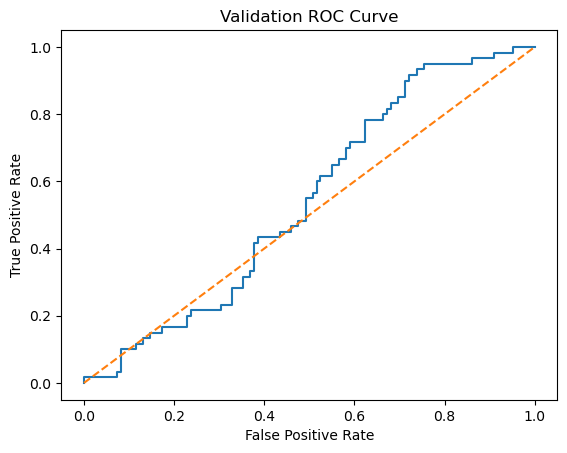

Confusion Matrix:
[[  0 122]
 [  0  60]]
016 | 0.9370 | 0.9267 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6490 | 0.4954 | 0.0000
017 | 0.9312 | 0.9275 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6530 | 0.4894 | 0.0000
018 | 0.9342 | 0.9267 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6533 | 0.4871 | 0.0000
019 | 0.9331 | 0.9260 | 0.3567 | 0.3956 | 0.5365 | 0.3476 | 0.9500 | 0.6500 | 0.4818 | 0.1149
020 | 0.9296 | 0.9263 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6525 | 0.4864 | 0.0000
021 | 0.9361 | 0.9275 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6533 | 0.4837 | 0.0000
022 | 0.9318 | 0.9258 | 0.6570 | 0.6703 | 0.6059 | 0.5000 | 0.4167 | 0.6490 | 0.4750 | 0.2230
023 | 0.9314 | 0.9262 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6493 | 0.4740 | 0.0000
024 | 0.9327 | 0.9262 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6455 | 0.4697 | 0.0000
025 | 0.9335 | 0.9266 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6496 | 0.4804 | 0.0000
026 | 0.9310 | 0.92

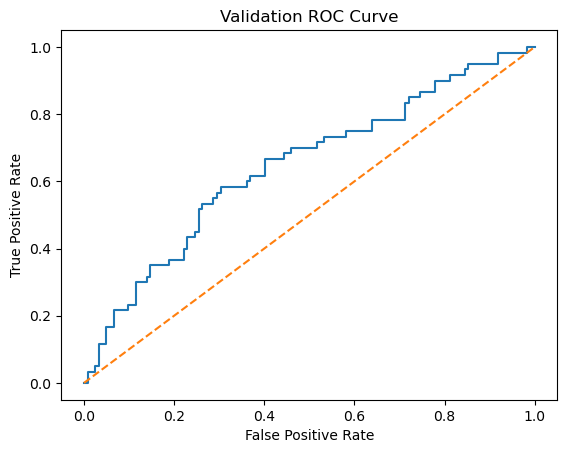

Confusion Matrix:
[[  2 120]
 [  0  60]]
031 | 0.9321 | 0.9262 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6544 | 0.4906 | 0.0000
032 | 0.9327 | 0.9257 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6488 | 0.4711 | 0.0000
033 | 0.9334 | 0.9251 | 0.3320 | 0.3407 | 0.5082 | 0.3333 | 1.0000 | 0.6473 | 0.4675 | 0.0739
034 | 0.9318 | 0.9253 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6481 | 0.4682 | 0.0000
035 | 0.9350 | 0.9243 | 0.6157 | 0.6429 | 0.6277 | 0.4667 | 0.5833 | 0.6402 | 0.4546 | 0.2440
036 | 0.9370 | 0.9264 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6578 | 0.5007 | 0.0000
037 | 0.9313 | 0.9265 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6557 | 0.4841 | 0.0000
038 | 0.9345 | 0.9257 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6561 | 0.4883 | 0.0000
039 | 0.9338 | 0.9254 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6533 | 0.4892 | 0.0000
040 | 0.9337 | 0.9255 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6546 | 0.4900 | 0.0000
041 | 0.9301 | 0.92

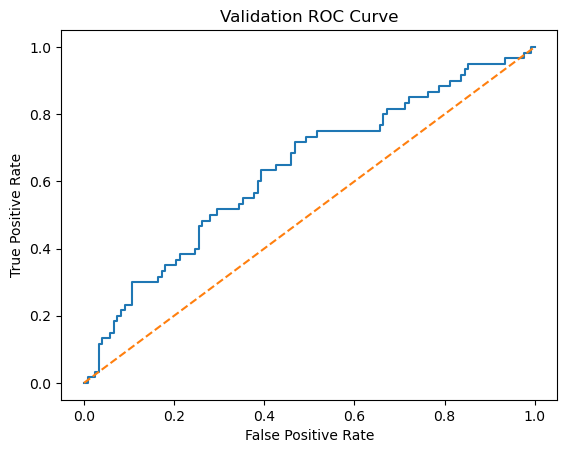

Confusion Matrix:
[[  1 121]
 [  0  60]]
046 | 0.9278 | 0.9238 | 0.4449 | 0.4780 | 0.5641 | 0.3684 | 0.8167 | 0.6410 | 0.4706 | 0.1358
047 | 0.9274 | 0.9212 | 0.6694 | 0.6758 | 0.5126 | 0.6667 | 0.0333 | 0.6464 | 0.4669 | 0.0928
048 | 0.9320 | 0.9230 | 0.3953 | 0.4066 | 0.5404 | 0.3500 | 0.9333 | 0.6455 | 0.4662 | 0.1166
049 | 0.9249 | 0.9157 | 0.6722 | 0.6703 | 0.5678 | 0.5000 | 0.2667 | 0.6454 | 0.4650 | 0.1674
050 | 0.9282 | 0.9256 | 0.3278 | 0.3297 | 0.5000 | 0.3297 | 1.0000 | 0.6553 | 0.4953 | 0.0000
051 | 0.9275 | 0.9230 | 0.6680 | 0.6923 | 0.5842 | 0.5714 | 0.2667 | 0.6544 | 0.4844 | 0.2193
052 | 0.9313 | 0.9225 | 0.6736 | 0.6648 | 0.4959 | 0.0000 | 0.0000 | 0.6545 | 0.4830 | -0.0521
053 | 0.9372 | 0.9227 | 0.4229 | 0.4396 | 0.5396 | 0.3521 | 0.8333 | 0.6546 | 0.4844 | 0.0899
054 | 0.9292 | 0.9231 | 0.4077 | 0.4341 | 0.5567 | 0.3595 | 0.9167 | 0.6530 | 0.4821 | 0.1456
055 | 0.9278 | 0.9239 | 0.3444 | 0.3571 | 0.5163 | 0.3371 | 0.9833 | 0.6542 | 0.4805 | 0.0795
056 | 0.9334 | 0.9

/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


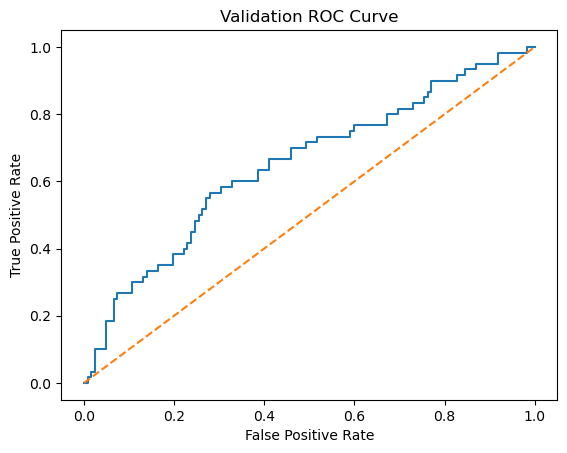

Confusion Matrix:
[[122   0]
 [ 60   0]]
061 | 0.9260 | 0.9188 | 0.3898 | 0.4011 | 0.5363 | 0.3478 | 0.9333 | 0.6495 | 0.4734 | 0.1069
062 | 0.9240 | 0.9096 | 0.5482 | 0.5934 | 0.6163 | 0.4271 | 0.6833 | 0.6471 | 0.4706 | 0.2189
063 | 0.9297 | 0.9202 | 0.3554 | 0.3681 | 0.5160 | 0.3373 | 0.9500 | 0.6548 | 0.4735 | 0.0584
064 | 0.9257 | 0.9166 | 0.5895 | 0.6099 | 0.6031 | 0.4321 | 0.5833 | 0.6422 | 0.4708 | 0.1951
065 | 0.9188 | 0.9150 | 0.4353 | 0.4341 | 0.5567 | 0.3595 | 0.9167 | 0.6474 | 0.4660 | 0.1456
066 | 0.9180 | 0.9016 | 0.5579 | 0.5714 | 0.5872 | 0.4043 | 0.6333 | 0.6329 | 0.4459 | 0.1640
067 | 0.9331 | 0.9100 | 0.6598 | 0.6429 | 0.6023 | 0.4603 | 0.4833 | 0.6370 | 0.4761 | 0.2022
068 | 0.9043 | 0.8889 | 0.6074 | 0.6319 | 0.6068 | 0.4507 | 0.5333 | 0.6436 | 0.4684 | 0.2059
069 | 0.9171 | 0.8920 | 0.6570 | 0.6648 | 0.6187 | 0.4915 | 0.4833 | 0.6439 | 0.4738 | 0.2385
070 | 0.8974 | 0.8873 | 0.6061 | 0.5824 | 0.5657 | 0.3974 | 0.5167 | 0.6343 | 0.4550 | 0.1248
071 | 0.8831 | 0.89

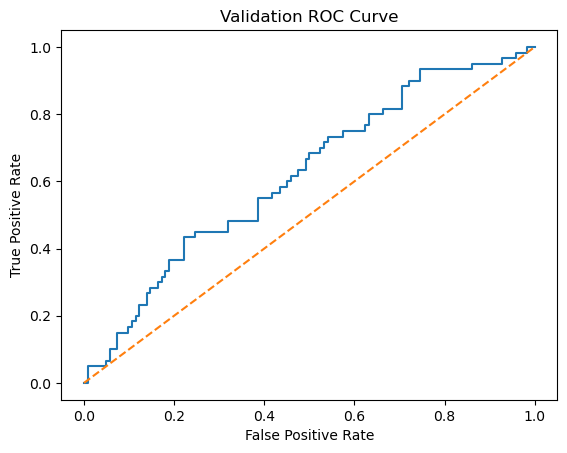

Confusion Matrix:
[[114   8]
 [ 54   6]]
076 | 0.9096 | 0.9021 | 0.7039 | 0.6593 | 0.5723 | 0.4750 | 0.3167 | 0.6254 | 0.4452 | 0.1641
077 | 0.8910 | 0.8957 | 0.6818 | 0.5989 | 0.5695 | 0.4085 | 0.4833 | 0.6160 | 0.4166 | 0.1340
078 | 0.8473 | 0.9414 | 0.6143 | 0.5055 | 0.5422 | 0.3611 | 0.6500 | 0.5787 | 0.3942 | 0.0808
079 | 0.8284 | 0.9033 | 0.6474 | 0.5989 | 0.6077 | 0.4270 | 0.6333 | 0.6112 | 0.4065 | 0.2025
080 | 0.8787 | 0.9169 | 0.7300 | 0.6374 | 0.5898 | 0.4500 | 0.4500 | 0.6092 | 0.4105 | 0.1795
081 | 0.8102 | 0.9586 | 0.7548 | 0.6319 | 0.5475 | 0.4186 | 0.3000 | 0.6022 | 0.3901 | 0.1052
082 | 0.8064 | 0.9538 | 0.7590 | 0.6319 | 0.5687 | 0.4340 | 0.3833 | 0.5919 | 0.3837 | 0.1422
083 | 0.8425 | 0.9354 | 0.7438 | 0.6484 | 0.6022 | 0.4667 | 0.4667 | 0.5933 | 0.3835 | 0.2044
084 | 0.7866 | 1.0173 | 0.7782 | 0.6264 | 0.5519 | 0.4167 | 0.3333 | 0.5967 | 0.3785 | 0.1108
085 | 0.7751 | 0.9973 | 0.4945 | 0.4396 | 0.5481 | 0.3562 | 0.8667 | 0.5536 | 0.3625 | 0.1135
086 | 0.8097 | 0.94

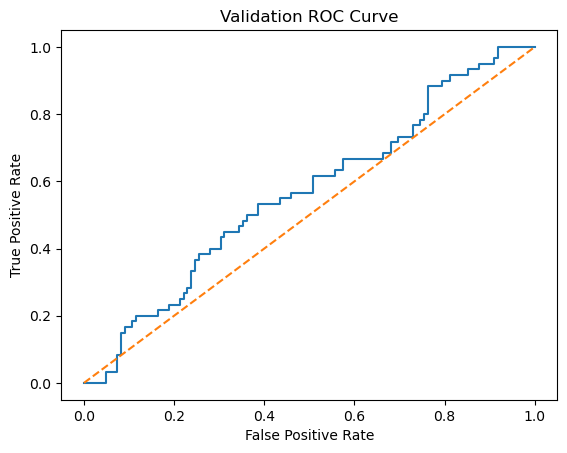

Confusion Matrix:
[[66 56]
 [26 34]]
091 | 0.7123 | 0.9531 | 0.6997 | 0.5495 | 0.5623 | 0.3830 | 0.6000 | 0.5691 | 0.3766 | 0.1172
092 | 0.6857 | 1.1576 | 0.8485 | 0.6209 | 0.5732 | 0.4262 | 0.4333 | 0.5536 | 0.3639 | 0.1458
093 | 0.6069 | 1.2581 | 0.8691 | 0.6154 | 0.5522 | 0.4074 | 0.3667 | 0.5645 | 0.3646 | 0.1074
094 | 0.5905 | 1.2777 | 0.8760 | 0.6374 | 0.5432 | 0.4211 | 0.2667 | 0.5824 | 0.3797 | 0.0999
095 | 0.6301 | 1.2983 | 0.8774 | 0.5879 | 0.5486 | 0.3881 | 0.4333 | 0.5701 | 0.3641 | 0.0948
096 | 0.5643 | 1.2692 | 0.8843 | 0.6209 | 0.5775 | 0.4286 | 0.4500 | 0.5776 | 0.3850 | 0.1531
097 | 0.4850 | 1.6785 | 0.8912 | 0.6319 | 0.5348 | 0.4054 | 0.2500 | 0.5847 | 0.3808 | 0.0814
098 | 0.4973 | 1.3547 | 0.8499 | 0.5879 | 0.5698 | 0.4026 | 0.5167 | 0.5762 | 0.3866 | 0.1328
099 | 0.4698 | 1.4558 | 0.8347 | 0.5769 | 0.5531 | 0.3867 | 0.4833 | 0.5902 | 0.3918 | 0.1015
100 | 0.4561 | 1.9155 | 0.9105 | 0.5989 | 0.5568 | 0.4000 | 0.4333 | 0.5706 | 0.3753 | 0.1115
101 | 0.4288 | 1.9420 |

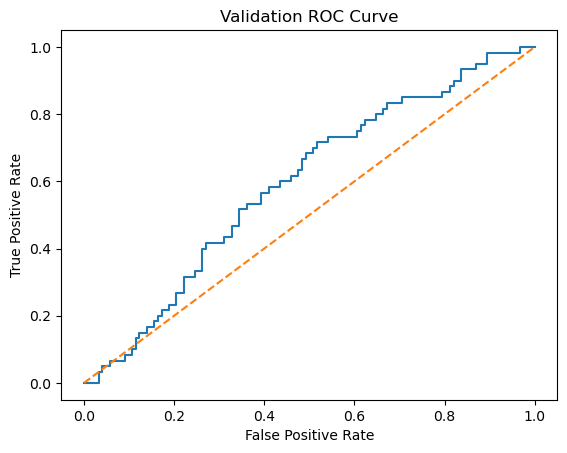

Confusion Matrix:
[[59 63]
 [17 43]]
106 | 0.3760 | 2.1647 | 0.9339 | 0.6154 | 0.5691 | 0.4194 | 0.4333 | 0.5910 | 0.3779 | 0.1371
107 | 0.3337 | 2.0978 | 0.9408 | 0.6209 | 0.5309 | 0.3902 | 0.2667 | 0.6158 | 0.4087 | 0.0695
108 | 0.3533 | 2.1683 | 0.9366 | 0.6154 | 0.5607 | 0.4138 | 0.4000 | 0.6224 | 0.3977 | 0.1224
109 | 0.3048 | 2.2247 | 0.9532 | 0.6154 | 0.5183 | 0.3684 | 0.2333 | 0.6137 | 0.3932 | 0.0423
110 | 0.2472 | 2.4796 | 0.9656 | 0.6264 | 0.5731 | 0.4310 | 0.4167 | 0.6199 | 0.3954 | 0.1475
111 | 0.3004 | 2.4609 | 0.9380 | 0.6374 | 0.5432 | 0.4211 | 0.2667 | 0.6199 | 0.4045 | 0.0999
112 | 0.3102 | 1.8290 | 0.9050 | 0.6044 | 0.6033 | 0.4286 | 0.6000 | 0.6059 | 0.3880 | 0.1948
113 | 0.2485 | 2.6421 | 0.9545 | 0.6099 | 0.5777 | 0.4203 | 0.4833 | 0.6117 | 0.3933 | 0.1506
114 | 0.1737 | 3.1992 | 0.9780 | 0.6209 | 0.5648 | 0.4211 | 0.4000 | 0.6305 | 0.4080 | 0.1313
115 | 0.2209 | 2.6891 | 0.9187 | 0.5989 | 0.5865 | 0.4177 | 0.5500 | 0.6108 | 0.3980 | 0.1640
116 | 0.3188 | 2.2100 |

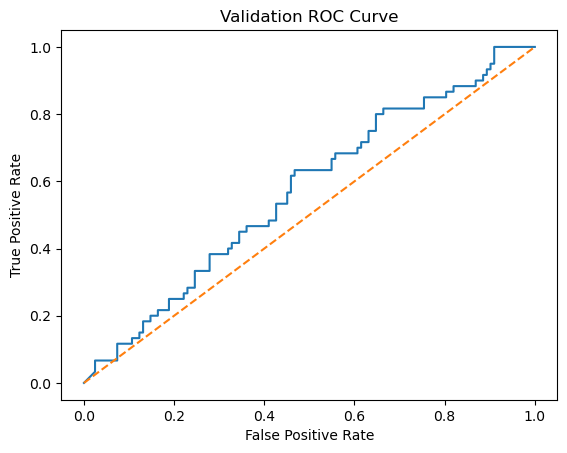

Confusion Matrix:
[[73 49]
 [32 28]]
121 | 0.3194 | 2.4435 | 0.9614 | 0.6209 | 0.5902 | 0.4348 | 0.5000 | 0.6111 | 0.3963 | 0.1747
122 | 0.2162 | 3.0075 | 0.9821 | 0.6099 | 0.5269 | 0.3778 | 0.2833 | 0.6044 | 0.3989 | 0.0587
123 | 0.2212 | 2.8079 | 0.9656 | 0.6264 | 0.5477 | 0.4130 | 0.3167 | 0.6236 | 0.4164 | 0.1031
124 | 0.1980 | 2.7046 | 0.9780 | 0.6319 | 0.5984 | 0.4478 | 0.5000 | 0.6148 | 0.3995 | 0.1917
125 | 0.1260 | 3.8816 | 0.9807 | 0.6209 | 0.5775 | 0.4286 | 0.4500 | 0.6190 | 0.3969 | 0.1531
126 | 0.2001 | 2.7207 | 0.9876 | 0.6593 | 0.5892 | 0.4792 | 0.3833 | 0.6193 | 0.4104 | 0.1903
127 | 0.1274 | 3.8852 | 0.9807 | 0.6374 | 0.5559 | 0.4318 | 0.3167 | 0.6094 | 0.4048 | 0.1227
128 | 0.1716 | 2.6960 | 0.8774 | 0.5604 | 0.5705 | 0.3913 | 0.6000 | 0.6055 | 0.4013 | 0.1326
129 | 0.2372 | 2.9187 | 0.9766 | 0.5989 | 0.5738 | 0.4110 | 0.5000 | 0.5828 | 0.3795 | 0.1415
130 | 0.1480 | 3.5911 | 0.9890 | 0.6264 | 0.5604 | 0.4231 | 0.3667 | 0.6176 | 0.4035 | 0.1257
131 | 0.1572 | 3.4231 |

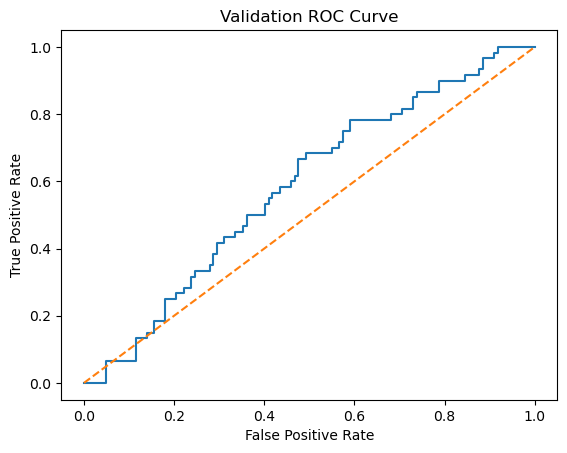

Confusion Matrix:
[[87 35]
 [37 23]]
136 | 0.1267 | 3.4537 | 0.9628 | 0.5879 | 0.5910 | 0.4138 | 0.6000 | 0.5913 | 0.3896 | 0.1712
137 | 0.1511 | 3.9251 | 0.9931 | 0.5879 | 0.5317 | 0.3729 | 0.3667 | 0.5908 | 0.3877 | 0.0637
138 | 0.0924 | 4.2080 | 0.9573 | 0.6044 | 0.6117 | 0.4318 | 0.6333 | 0.5911 | 0.3926 | 0.2102
139 | 0.1173 | 4.3139 | 0.9890 | 0.6154 | 0.5903 | 0.4306 | 0.5167 | 0.5984 | 0.3989 | 0.1736
140 | 0.1020 | 4.4793 | 0.9972 | 0.6154 | 0.5649 | 0.4167 | 0.4167 | 0.6057 | 0.4022 | 0.1298
141 | 0.0662 | 5.8634 | 0.9780 | 0.5934 | 0.5189 | 0.3600 | 0.3000 | 0.6027 | 0.3950 | 0.0397
142 | 0.0888 | 5.5169 | 0.9931 | 0.5879 | 0.5232 | 0.3636 | 0.3333 | 0.5883 | 0.3773 | 0.0475
143 | 0.1350 | 4.8285 | 0.9986 | 0.6154 | 0.5522 | 0.4074 | 0.3667 | 0.5952 | 0.3801 | 0.1074
144 | 0.1118 | 4.0890 | 0.9931 | 0.6374 | 0.5855 | 0.4483 | 0.4333 | 0.6062 | 0.3982 | 0.1726
145 | 0.0753 | 4.5593 | 0.9959 | 0.5989 | 0.5653 | 0.4058 | 0.4667 | 0.6016 | 0.3904 | 0.1265
146 | 0.0811 | 4.8853 |

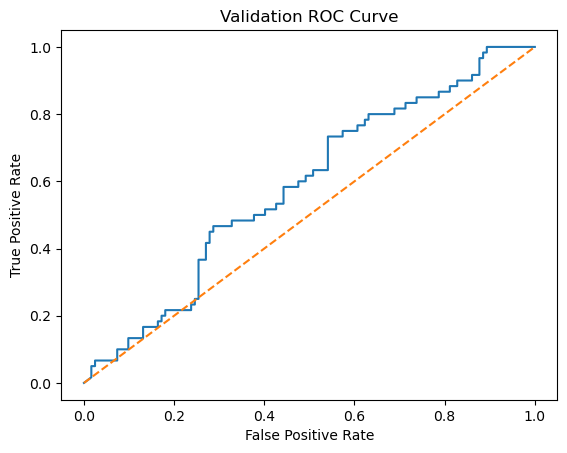

Confusion Matrix:
[[91 31]
 [44 16]]


In [32]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, confusion_matrix
import lib.metrics

train_losses = []
val_losses = []
num_epochs = 150

print("Epoch | Train_Loss | Val_Loss | Train_Acc | Val_Acc | Bal_Acc | Prec | Rec | AUROC | AUPRC | MCC")

for epoch in range(num_epochs):
    train_loss = train(model, train_loader, optimizer, criterion, device)
    train_acc  = evaluate(model, train_loader, device)
    val_loss   = evaluate_loss(model, val_loader, criterion, device)
    val_acc    = evaluate(model, val_loader, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    val_auc, labels, probs = evaluate_auc(model, val_loader, device)
    preds = (probs >= 0.5).astype(int)

    bal_acc = balanced_accuracy_score(labels, preds)
    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    auprc = average_precision_score(labels, probs)
    mcc = matthews_corrcoef(labels, preds)
    
    cm = confusion_matrix(labels, preds)

    print(
        f"{epoch+1:03d} | "
        f"{train_loss:.4f} | "
        f"{val_loss:.4f} | "
        f"{train_acc:.4f} | "
        f"{val_acc:.4f} | "
        f"{bal_acc:.4f} | "
        f"{precision:.4f} | "
        f"{recall:.4f} | "
        f"{val_auc:.4f} | "
        f"{auprc:.4f} | "
        f"{mcc:.4f}"
    )
    
    if (epoch+1) % 15 == 0:
        plot_roc(labels, probs)
        print("Confusion Matrix:")
        print(cm)

In [35]:
from sklearn.metrics import accuracy_score

p = labels.mean()  # prevalence of positive class

random_probs = np.full_like(labels, p, dtype=float)
random_preds = (random_probs >= 0.5).astype(int)

acc_rand = accuracy_score(labels, random_preds)
bal_acc_rand = balanced_accuracy_score(labels, random_preds)
precision_rand = precision_score(labels, random_preds, zero_division=0)
recall_rand = recall_score(labels, random_preds)
auroc_rand = roc_auc_score(labels, random_probs)
auprc_rand = average_precision_score(labels, random_probs)
mcc_rand = matthews_corrcoef(labels, random_preds)

print("Baseline (Random)")
print(
    f"Acc: {acc_rand:.4f} | "
    f"Bal_Acc: {bal_acc_rand:.4f} | "
    f"Prec: {precision_rand:.4f} | "
    f"Rec: {recall_rand:.4f} | "
    f"AUROC: {auroc_rand:.4f} | "
    f"AUPRC: {auprc_rand:.4f} | "
    f"MCC: {mcc_rand:.4f}"
)

Baseline (Random)
Acc: 0.6703 | Bal_Acc: 0.5000 | Prec: 0.0000 | Rec: 0.0000 | AUROC: 0.5000 | AUPRC: 0.3297 | MCC: 0.0000


In [14]:
import torch

def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        out = model(batch)          # shape: (batch_size, 1)
        out = out.view(-1)          # flatten to (batch_size,)
        y = batch.y.view(-1).float()  # ensure float for BCE
        
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch).view(-1)  # flatten
            y = batch.y.view(-1).float()
            
            pred = (torch.sigmoid(out) > 0.5).float()
            
            correct += (pred == y).sum().item()
            total += y.size(0)
    
    return correct / total

def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch).view(-1)
            y = batch.y.view(-1).float()
            
            loss = criterion(out, y)
            total_loss += loss.item()
    
    return total_loss / len(loader)



In [19]:
from sklearn.metrics import roc_auc_score, roc_curve
import torch

def evaluate_auc(model, loader, device):
    model.eval()
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch).view(-1)
            
            probs = torch.sigmoid(out)  # convert logits to probability
            all_probs.append(probs.cpu())
            all_labels.append(batch.y.view(-1).cpu())
    
    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()
    
    auc = roc_auc_score(all_labels, all_probs)
    return auc, all_labels, all_probs

def plot_roc(all_labels, all_probs):
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Validation ROC Curve")
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, confusion_matrix

num_epochs = 100

# store losses for plotting
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = train(model, train_loader, optimizer, criterion, device)
    train_acc  = evaluate(model, train_loader, device)
    val_loss   = evaluate_loss(model, val_loader, criterion, device)
    val_acc    = evaluate(model, val_loader, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    val_auc, labels, probs = evaluate_auc(model, val_loader, device)
    preds = (probs >= 0.5).astype(int)
    
    precision = precision_score(labels, preds)
    recall    = recall_score(labels, preds)
    cm        = confusion_matrix(labels, preds)
    
    print(
        f"Epoch {epoch+1:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val AUC: {val_auc:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f}"
    )
    
    if (epoch+1) % 5 == 0:
        plot_roc(labels, probs)
        print("Confusion Matrix:")
        print(cm)

# Final ROC plot
plot_roc(labels, probs)

# --- Plot train and val loss ---
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import torch

labels = torch.tensor([data.y.item() for data in dataset])

class_counts = torch.bincount(labels)
print("Class counts:", class_counts)

num_classes = len(class_counts)
total_samples = len(labels)

class_weights = total_samples / (num_classes * class_counts.float())
print("Class weights:", class_weights)


criterion = torch.nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)


In [ ]:
import torch

labels = torch.tensor([data.y.item() for data in dataset])

class_counts = torch.bincount(labels)
total_samples = len(labels)

majority_class_count = class_counts.max().item()

baseline_accuracy = majority_class_count / total_samples

print("Class counts:", class_counts.tolist())
print("Baseline accuracy:", baseline_accuracy)
